In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import os
import psutil # Pastikan sudah install: pip install psutil

# Import dasar untuk SklearnWrapper
from sklearn.base import BaseEstimator, RegressorMixin

# Import model-model yang digunakan dalam base_estimators
from sklearn.ensemble import (StackingRegressor, RandomForestRegressor, 
                              ExtraTreesRegressor, GradientBoostingRegressor, 
                              AdaBoostRegressor)
from sklearn.linear_model import RidgeCV, Lasso
from sklearn.svm import SVR

# Import model pihak ketiga (pastikan sudah install: pip install xgboost lightgbm catboost)
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

In [2]:
# 1. Baca data (gunakan header=None karena .data tidak punya nama kolom)
# Gunakan na_values='?' karena data yang hilang ditandai dengan tanda tanya
df = pd.read_csv('communities.data', header=None, na_values='?')

# 2. Ambil nama kolom dari file .names (atau buat manual)
# Karena ada 128 kolom, disarankan mengambil daftar namanya
# Untuk keperluan cepat, kita beri nama generic dulu:
df.columns = [f"feat_{i}" for i in range(df.shape[1])]

# 3. Target adalah kolom terakhir
target = 'feat_127'

# 4. Pra-pemrosesan (WAJIB untuk metode Anda)
# Buang kolom non-prediktif (seperti nama komunitas, state, dll - 5 kolom pertama)
df = df.iloc[:, 5:]

# Isi missing values (Imputation) sebelum masuk ke MrMiMaxG
df = df.fillna(df.mean())

print(df.head())
X = df.drop(columns=['feat_127'])
y = df['feat_127']

   feat_5  feat_6  feat_7  feat_8  feat_9  feat_10  feat_11  feat_12  feat_13  \
0    0.19    0.33    0.02    0.90    0.12     0.17     0.34     0.47     0.29   
1    0.00    0.16    0.12    0.74    0.45     0.07     0.26     0.59     0.35   
2    0.00    0.42    0.49    0.56    0.17     0.04     0.39     0.47     0.28   
3    0.04    0.77    1.00    0.08    0.12     0.10     0.51     0.50     0.34   
4    0.01    0.55    0.02    0.95    0.09     0.05     0.38     0.38     0.23   

   feat_14  ...  feat_118  feat_119  feat_120  feat_121  feat_122  feat_123  \
0     0.32  ...      0.12      0.26      0.20  0.060000  0.040000  0.900000   
1     0.27  ...      0.02      0.12      0.45  0.163103  0.076708  0.698589   
2     0.32  ...      0.01      0.21      0.02  0.163103  0.076708  0.698589   
3     0.21  ...      0.02      0.39      0.28  0.163103  0.076708  0.698589   
4     0.36  ...      0.04      0.09      0.02  0.163103  0.076708  0.698589   

   feat_124  feat_125  feat_126  feat_

In [3]:
df

,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,feat_11,feat_12,feat_13,feat_14,...,feat_118,feat_119,feat_120,feat_121,feat_122,feat_123,feat_124,feat_125,feat_126,feat_127
0,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,0.32,...,0.12,0.26,0.20,0.060000,0.040000,0.900000,0.500000,0.32,0.140000,0.20
1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,0.27,...,0.02,0.12,0.45,0.163103,0.076708,0.698589,0.440439,0.00,0.195078,0.67
2,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,0.32,...,0.01,0.21,0.02,0.163103,0.076708,0.698589,0.440439,0.00,0.195078,0.43
3,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,0.21,...,0.02,0.39,0.28,0.163103,0.076708,0.698589,0.440439,0.00,0.195078,0.12
4,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,0.23,0.36,...,0.04,0.09,0.02,0.163103,0.076708,0.698589,0.440439,0.00,0.195078,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,0.01,0.40,0.10,0.87,0.12,0.16,0.43,0.51,0.35,0.30,...,0.01,0.28,0.05,0.163103,0.076708,0.698589,0.440439,0.00,0.195078,0.09
1990,0.05,0.96,0.46,0.28,0.83,0.32,0.69,0.86,0.73,0.14,...,0.02,0.37,0.20,0.163103,0.076708,0.698589,0.440439,0.00,0.195078,0.45
1991,0.16,0.37,0.25,0.69,0.04,0.25,0.35,0.50,0.31,0.54,...,0.08,0.32,0.18,0.080000,0.060000,0.780000,0.000000,0.91,0.280000,0.23
1992,0.08,0.51,0.06,0.87,0.22,0.10,0.58,0.74,0.63,0.41,...,0.03,0.38,0.33,0.020000,0.020000,0.790000,0.000000,0.22,0.180000,0.19


In [4]:
# 2. SETUP EKSPERIMEN
sample_sizes = np.linspace(0.1, 1.0, 10) 
n_records = []
training_times = []
inference_times = []



In [5]:
# --- COMPATIBILITY WRAPPER (FIXED for sklearn 1.8.0 Tags system) ---
class SklearnWrapper(BaseEstimator, RegressorMixin):
    """Wrapper untuk kompatibilitas dengan sklearn StackingRegressor"""
    def __init__(self, model):
        self.model = model
    
    def fit(self, X, y, **fit_params):
        self.model.fit(X, y, **fit_params)
        return self
    
    def predict(self, X):
        return self.model.predict(X)
    
    def get_params(self, deep=True):
        return {"model": self.model}
    
    def set_params(self, **params):
        if "model" in params:
            self.model = params["model"]
        return self
    
    # Implement __sklearn_tags__ for proper regressor detection in sklearn 1.8.0+
    def __sklearn_tags__(self):
        from sklearn.utils._tags import Tags, RegressorTags, TargetTags, InputTags
        tags = Tags(
            estimator_type="regressor",
            target_tags=TargetTags(
                required=False,
                one_d_labels=False,
                two_d_labels=False,
                positive_only=False,
                multi_output=False,
                single_output=True
            ),
            regressor_tags=RegressorTags(),
            input_tags=InputTags()
        )
        return tags


# ==========================================
# 3. LOOPING UNTUK MENGUKUR WAKTU
# ==========================================
print(f"{'N':<8} | {'Train Time (s)':<15} | {'Inf Time (s)':<15}")
print("-" * 45)

# 3. LOOPING PENGUKURAN
for prop in sample_sizes:
    n = int(len(df) * prop)
    X_subset = X.iloc[:n]
    y_subset = y.iloc[:n]
    n_records.append(n)

    # ----------------------------------------------------
    # SETUP STACKING REGRESSOR
    # ----------------------------------------------------
    # 1. Definisikan Base Models (Sesuaikan dengan model di notebook Anda)
    # Contoh di bawah ini menggunakan Random Forest dan XGBoost
    base_estimators = [
   ('xgb', SklearnWrapper(xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42))),
    ('cat', SklearnWrapper(CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_state=42))),
    ('lgbm', SklearnWrapper(lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, verbosity=-1, random_state=42))),
    ('rf', RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)),
    ('et', ExtraTreesRegressor(n_estimators=300, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=300, random_state=42)),
    ('ada', AdaBoostRegressor(n_estimators=100, random_state=42)),
    ('svr', SklearnWrapper(SVR(C=1.0, epsilon=0.1))),
    ('lasso', Lasso(alpha=0.01))
    ]
    
    # 2. Definisikan Final Estimator (Meta-model)
    final_estimator = RidgeCV()
    
    # 3. Gabungkan ke dalam StackingRegressor
    model = StackingRegressor(
        estimators=base_estimators,
        final_estimator=final_estimator,
        cv=5 # Menggunakan 5-fold cross validation saat melatih meta-model
    )
    # ----------------------------------------------------
    
    # --- PENGUKURAN TRAINING ---
    start_train = time.time()
    model.fit(X_subset, y_subset)
    end_train = time.time()
    training_times.append(end_train - start_train)

    # --- PENGUKURAN INFERENCE (DETEKSI) ---
    start_inf = time.time()
    model.predict(X_subset)
    end_inf = time.time()
    inference_times.append(end_inf - start_inf)

    print(f"{n:<8} | {training_times[-1]:<15.4f} | {inference_times[-1]:<15.4f}")

N        | Train Time (s)  | Inf Time (s)   
---------------------------------------------
199      | 20.7490         | 0.0541         
398      | 35.2300         | 0.1208         
598      | 51.9048         | 0.1844         
797      | 67.9361         | 0.2553         
997      | 80.0942         | 0.3002         
1196     | 96.0826         | 0.3413         
1395     | 108.7908        | 0.3703         
1595     | 124.6177        | 0.3791         
1794     | 136.0244        | 0.4204         
1994     | 154.4796        | 0.5704         


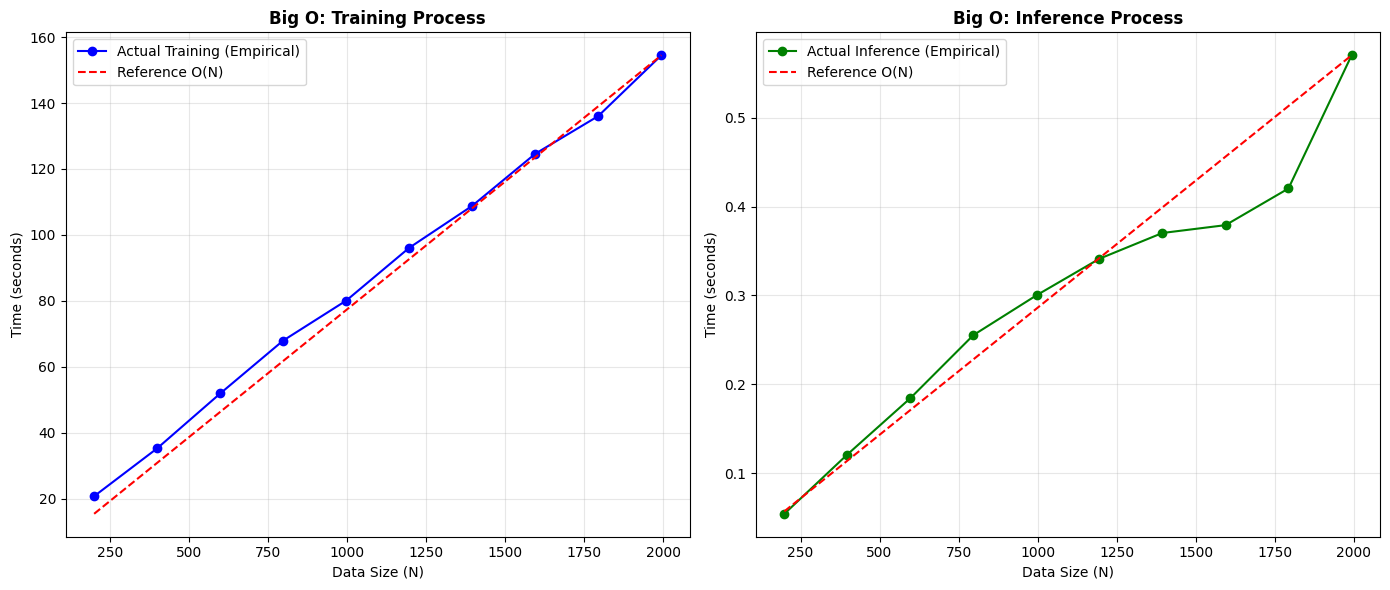

In [6]:
# 4. VISUALISASI PERBANDINGAN BIG O
plt.figure(figsize=(14, 6))

# Subplot 1: Training
plt.subplot(1, 2, 1)
plt.plot(n_records, training_times, 'bo-', label='Actual Training (Empirical)')
train_linear = [training_times[-1] * (n / n_records[-1]) for n in n_records]
plt.plot(n_records, train_linear, 'r--', label='Reference O(N)')
plt.title('Big O: Training Process', fontweight='bold')
plt.xlabel('Data Size (N)')
plt.ylabel('Time (seconds)')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Inference
plt.subplot(1, 2, 2)
plt.plot(n_records, inference_times, 'go-', label='Actual Inference (Empirical)')
inf_linear = [inference_times[-1] * (n / n_records[-1]) for n in n_records]
plt.plot(n_records, inf_linear, 'r--', label='Reference O(N)')
plt.title('Big O: Inference Process', fontweight='bold')
plt.xlabel('Data Size (N)')
plt.ylabel('Time (seconds)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()